# train_mlp_pattern_v3.ipynb
**MLP + Edge Embeddings** — batch-by-batch training

**Runs from:** `backend/model training/`

In [1]:
import os, pickle, time, warnings, gc, glob
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore'); sns.set_theme(style='darkgrid')

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME='mlp_pattern'; MODEL_DISPLAY='MLP Pattern'
EMBED_DIM=32; BATCH_SIZE=8192; LR=2e-3; WARMUP_EP=5; PATIENCE=15; MAX_EPOCHS=80; WD=1e-4

DATA_DIR='../data generation/data'
PATTERN_DIR=f'{DATA_DIR}/pattern_features'; SCALER_DIR=f'{DATA_DIR}/scalers'
MODEL_DIR=f'../models/{MODEL_NAME}'; os.makedirs(MODEL_DIR, exist_ok=True)
def _save(o,p): torch.save(o,str(Path(p).resolve()))
def _load(p,**k): return torch.load(str(Path(p).resolve()),**k)

with open(f'{PATTERN_DIR}/pattern_meta.pkl','rb') as f: meta=pickle.load(f)
with open(f'{SCALER_DIR}/scaler_pattern_ttr.pkl','rb') as f: scaler_ttr=pickle.load(f)
with open(f'{SCALER_DIR}/scaler_pattern_cong.pkl','rb') as f: scaler_cong=pickle.load(f)
FEATURES=meta['pattern_features']; NF=meta['n_features']; NE=meta['n_edges']
batch_files=sorted(glob.glob(f'{PATTERN_DIR}/batch_*.parquet'))
print(f'Features: {NF}, Edges: {NE:,}, Batches: {len(batch_files)}')

Features: 63, Edges: 145,265, Batches: 30


In [2]:
class MLPPattern(nn.Module):
    def __init__(self, nc, ne, ed=32):
        super().__init__()
        self.emb=nn.Embedding(ne,ed)
        self.net=nn.Sequential(nn.Linear(nc+ed,256),nn.ReLU(),nn.Dropout(.1),
            nn.Linear(256,256),nn.ReLU(),nn.Dropout(.1),nn.Linear(256,128),nn.ReLU(),nn.Dropout(.05),nn.Linear(128,1))
    def forward(self,x,idx): return self.net(torch.cat([x,self.emb(idx)],dim=-1)).squeeze(-1)

def train_mlp(target_col, save_name, tname):
    print(f'\n{"="*50}\n  MLP — {tname}\n{"="*50}')
    model=MLPPattern(NF,NE,EMBED_DIM).to(device)
    opt=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WD)
    sched=torch.optim.lr_scheduler.ReduceLROnPlateau(opt,'min',factor=.5,patience=7,min_lr=1e-6)
    crit=nn.SmoothL1Loss(); best=float('inf'); pat=0; hist={'train_loss':[],'val_loss':[]}
    print(f'  Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

    for epoch in range(MAX_EPOCHS):
        te=time.perf_counter()
        for pg in opt.param_groups: pg['lr']=LR*min(1,(epoch+1)/WARMUP_EP)
        model.train(); eloss=0; ns=0
        for bf in np.random.permutation(batch_files):
            df=pd.read_parquet(bf); tr=df[df['split']=='train']
            if len(tr)==0: del df; continue
            X=torch.from_numpy(tr[FEATURES].values.astype(np.float32))
            I=torch.from_numpy(tr['edge_idx'].values.astype(np.int64))
            Y=torch.from_numpy(tr[target_col].values.astype(np.float32))
            perm=np.random.permutation(len(X))
            for s in range(0,len(perm),BATCH_SIZE):
                e=min(s+BATCH_SIZE,len(perm)); bi=perm[s:e]
                opt.zero_grad(); loss=crit(model(X[bi].to(device),I[bi].to(device)),Y[bi].to(device))
                loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),5.); opt.step()
                eloss+=loss.item()*(e-s); ns+=(e-s)
            del df,tr,X,I,Y; gc.collect()
        tl=eloss/max(ns,1)

        model.eval(); vloss=0; vn=0
        with torch.no_grad():
            for bf in batch_files:
                df=pd.read_parquet(bf); v=df[df['split']=='val']
                if len(v)==0: del df; continue
                X=torch.from_numpy(v[FEATURES].values.astype(np.float32))
                I=torch.from_numpy(v['edge_idx'].values.astype(np.int64))
                Y=torch.from_numpy(v[target_col].values.astype(np.float32))
                for s in range(0,len(X),BATCH_SIZE*2):
                    e=min(s+BATCH_SIZE*2,len(X))
                    vloss+=crit(model(X[s:e].to(device),I[s:e].to(device)),Y[s:e].to(device)).item()*(e-s); vn+=(e-s)
                del df,v,X,I,Y; gc.collect()
        vl=vloss/max(vn,1); hist['train_loss'].append(tl); hist['val_loss'].append(vl)
        if epoch>=WARMUP_EP: sched.step(vl)
        mk=''
        if vl<best: best=vl; pat=0; _save(model.state_dict(),f'{MODEL_DIR}/{save_name}'); mk=' ★'
        else: pat+=1
        print(f'  Ep {epoch+1:3d} | trn={tl:.5f} val={vl:.5f} | {time.perf_counter()-te:.0f}s{mk}')
        if pat>=PATIENCE: print('  Early stop'); break
        torch.cuda.empty_cache()

    model.load_state_dict(_load(f'{MODEL_DIR}/{save_name}',weights_only=True))
    model.eval(); preds=[]
    with torch.no_grad():
        for bf in batch_files:
            df=pd.read_parquet(bf); te=df[df['split']=='test']
            if len(te)==0: del df; continue
            X=torch.from_numpy(te[FEATURES].values.astype(np.float32))
            I=torch.from_numpy(te['edge_idx'].values.astype(np.int64))
            for s in range(0,len(X),BATCH_SIZE*2):
                e=min(s+BATCH_SIZE*2,len(X))
                preds.append(model(X[s:e].to(device),I[s:e].to(device)).cpu().numpy())
            del df,te,X,I; gc.collect()
    return np.concatenate(preds), hist

ttr_pred,hist_ttr=train_mlp('travel_time_ratio','best_ttr.pt','TTR')
torch.cuda.empty_cache(); gc.collect()
cong_pred,hist_cong=train_mlp('congestion_level','best_cong.pt','Congestion')

# Collect test actuals + fftt
ttr_act,cong_act,fftt,harr=[],[],[],[]
for bf in batch_files:
    df=pd.read_parquet(bf); te=df[df['split']=='test']
    if len(te):
        ttr_act.append(te['travel_time_ratio'].values.astype(np.float32))
        cong_act.append(te['congestion_level'].values.astype(np.float32))
        ff_col = 'static_free_flow_travel_time' if 'static_free_flow_travel_time' in te.columns else 'free_flow_travel_time'
        fftt.append(te[ff_col].values.astype(np.float32) if ff_col in te.columns else np.full(len(te),30.,dtype=np.float32))
        harr.append(te['hour_of_day'].values if 'hour_of_day' in te.columns else np.zeros(len(te),dtype=np.int8))
    del df; gc.collect()
ttr_act_test=np.concatenate(ttr_act); cong_act_test=np.concatenate(cong_act)
fftt_test=np.concatenate(fftt); hour_arr=np.concatenate(harr)

ttr_pred_inv=ttr_pred*scaler_ttr.scale_[0]+scaler_ttr.mean_[0]; ttr_act_inv=ttr_act_test*scaler_ttr.scale_[0]+scaler_ttr.mean_[0]
cong_pred_inv=cong_pred*scaler_cong.scale_[0]+scaler_cong.mean_[0]; cong_act_inv=cong_act_test*scaler_cong.scale_[0]+scaler_cong.mean_[0]
ttr_pred_sec=ttr_pred_inv*fftt_test; ttr_act_sec=ttr_act_inv*fftt_test
for n,p,a in [('TTR',ttr_pred_inv,ttr_act_inv),('TTR s',ttr_pred_sec,ttr_act_sec),('Cng',cong_pred_inv,cong_act_inv)]:
    print(f'{n}: MAE={mean_absolute_error(a,p):.4f} R²={r2_score(a,p):.4f}')
print(f'\n✓ Both saved to {MODEL_DIR}/')


  MLP — TTR
  Params: 4,771,873
  Ep   1 | trn=0.02158 val=0.05739 | 93s ★
  Ep   2 | trn=0.01328 val=0.04858 | 76s ★
  Ep   3 | trn=0.01288 val=0.04117 | 58s ★
  Ep   4 | trn=0.01177 val=0.04482 | 59s
  Ep   5 | trn=0.01237 val=0.05069 | 58s
  Ep   6 | trn=0.01215 val=0.04952 | 58s
  Ep   7 | trn=0.01063 val=0.05087 | 59s
  Ep   8 | trn=0.01075 val=0.05370 | 57s
  Ep   9 | trn=0.00995 val=0.05102 | 57s
  Ep  10 | trn=0.01067 val=0.06502 | 57s
  Ep  11 | trn=0.00971 val=0.05125 | 57s
  Ep  12 | trn=0.00990 val=0.05490 | 58s
  Ep  13 | trn=0.00977 val=0.05389 | 58s
  Ep  14 | trn=0.00935 val=0.06020 | 57s
  Ep  15 | trn=0.00946 val=0.04961 | 58s
  Ep  16 | trn=0.00925 val=0.05204 | 58s
  Ep  17 | trn=0.00904 val=0.05768 | 58s
  Ep  18 | trn=0.00918 val=0.06233 | 57s
  Early stop

  MLP — Congestion
  Params: 4,771,873
  Ep   1 | trn=0.02673 val=0.05340 | 57s ★
  Ep   2 | trn=0.01434 val=0.05363 | 57s
  Ep   3 | trn=0.01442 val=0.04404 | 57s ★
  Ep   4 | trn=0.01303 val=0.05509 | 57s
  

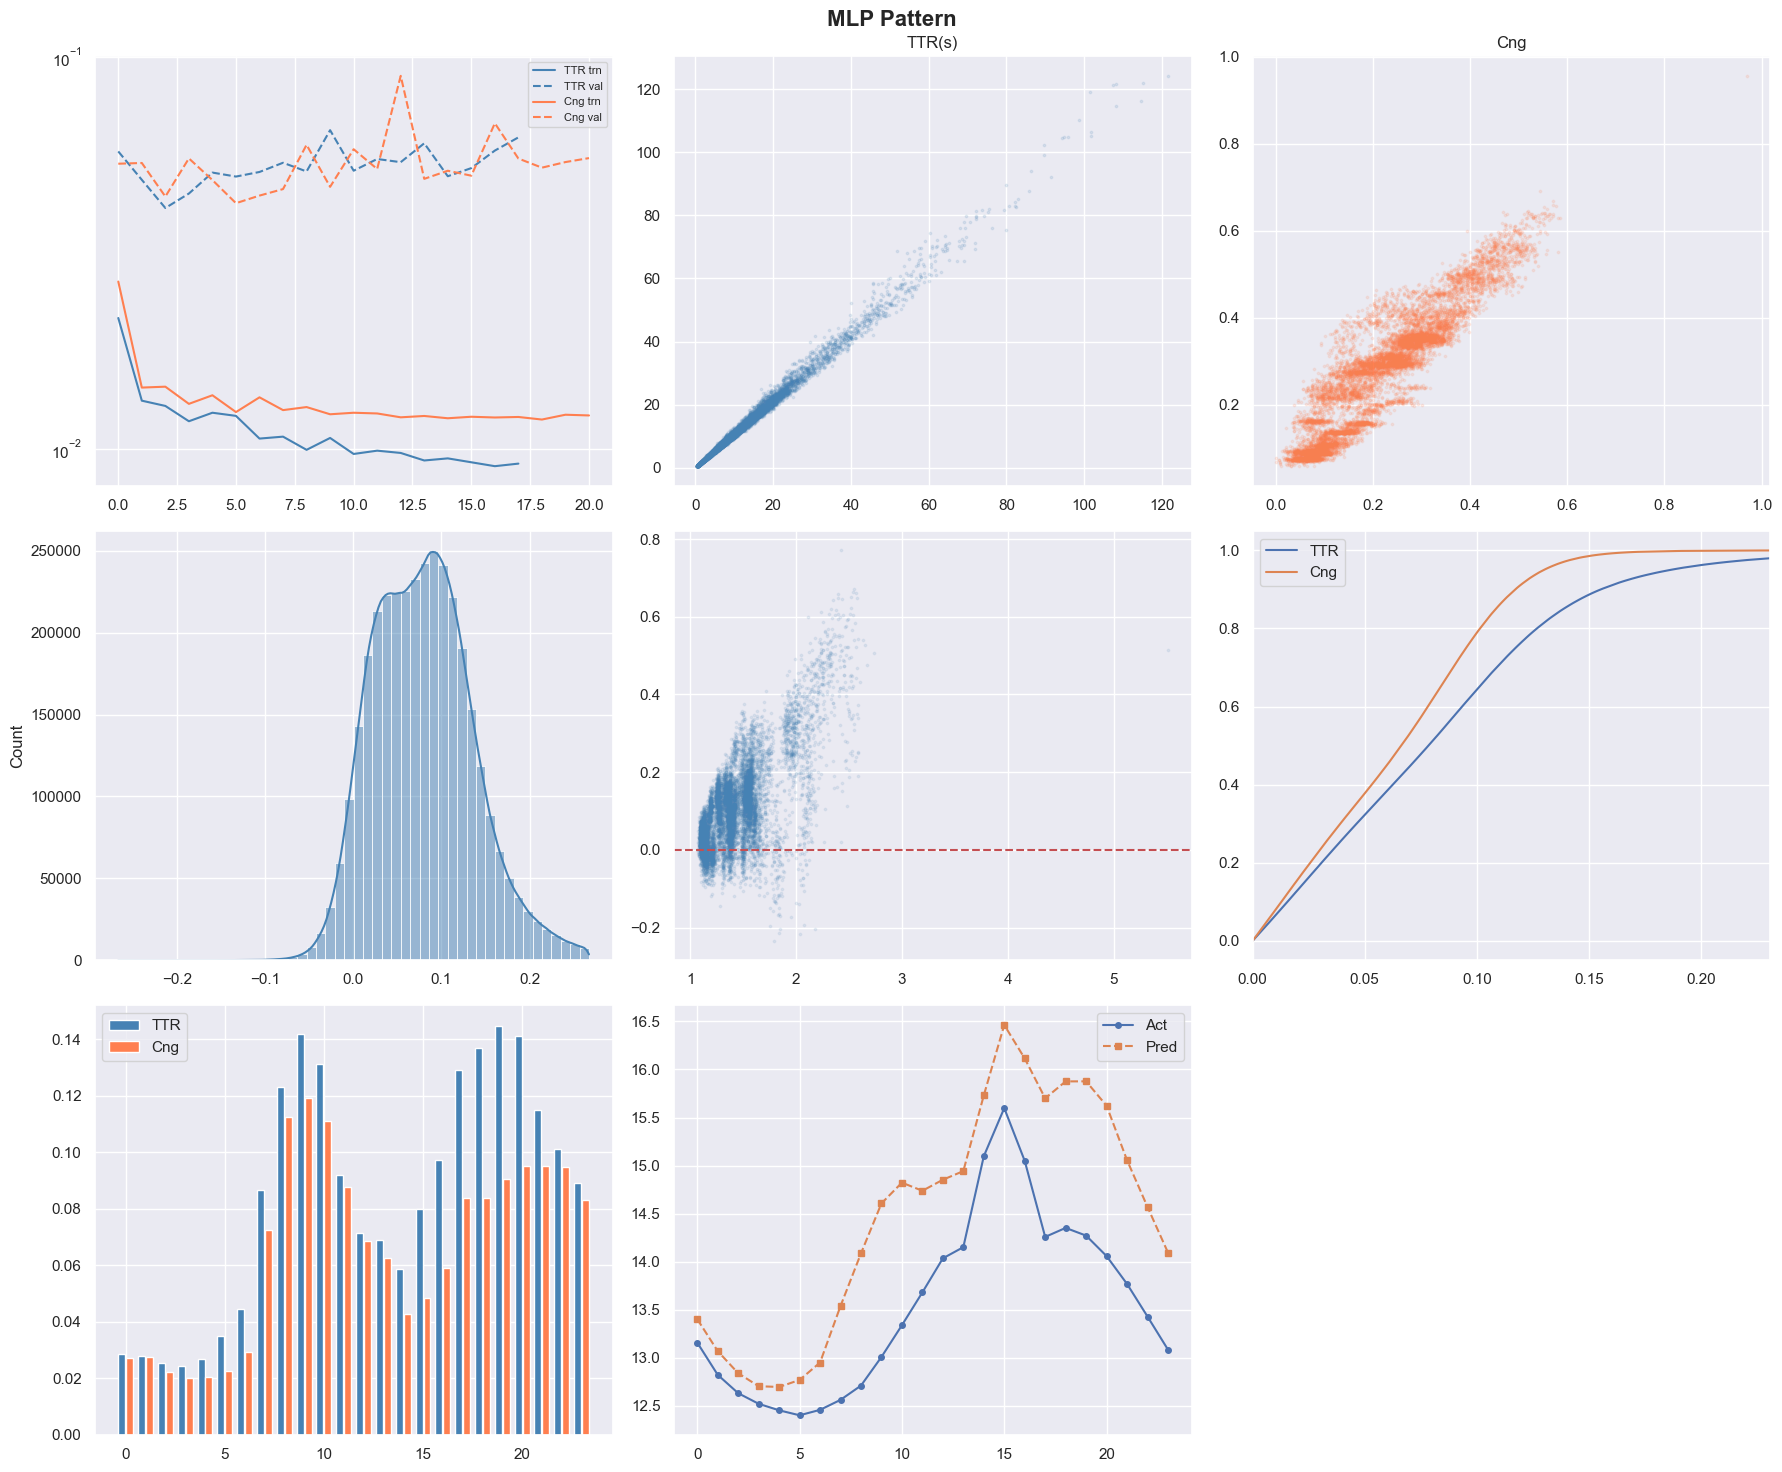

✓ MLP Pattern complete.


In [4]:
fig,axes=plt.subplots(3,3,figsize=(18,15)); fig.suptitle(f'{MODEL_DISPLAY}',fontsize=16,fontweight='bold')
ax=axes[0,0]; ax.plot(hist_ttr['train_loss'],label='TTR trn',c='steelblue'); ax.plot(hist_ttr['val_loss'],label='TTR val',c='steelblue',ls='--')
ax.plot(hist_cong['train_loss'],label='Cng trn',c='coral'); ax.plot(hist_cong['val_loss'],label='Cng val',c='coral',ls='--'); ax.legend(fontsize=8); ax.set_yscale('log')
ns=min(10000,len(ttr_pred_sec)); ii=np.random.choice(ns,ns,replace=False)
axes[0,1].scatter(ttr_act_sec[ii],ttr_pred_sec[ii],alpha=.12,s=3,c='steelblue'); axes[0,1].set_title('TTR(s)')
axes[0,2].scatter(cong_act_inv[ii],cong_pred_inv[ii],alpha=.12,s=3,c='coral'); axes[0,2].set_title('Cng')
te=ttr_pred_inv-ttr_act_inv; ce=cong_pred_inv-cong_act_inv
sns.histplot(te[np.abs(te)<np.percentile(np.abs(te),99)],kde=True,ax=axes[1,0],color='steelblue',bins=50)
axes[1,1].scatter(ttr_pred_inv[ii],te[ii],alpha=.1,s=3,c='steelblue'); axes[1,1].axhline(0,c='r',ls='--')
ta=np.sort(np.abs(te)); ca=np.sort(np.abs(ce)); axes[1,2].plot(ta,np.linspace(0,1,len(ta)),label='TTR')
axes[1,2].plot(ca,np.linspace(0,1,len(ca)),label='Cng'); axes[1,2].set_xlim(0,np.percentile(ta,98)); axes[1,2].legend()
th=sorted(set(hour_arr))
axes[2,0].bar([h-.2 for h in th],[mean_absolute_error(ttr_act_inv[hour_arr==h],ttr_pred_inv[hour_arr==h]) for h in th],.35,label='TTR',color='steelblue')
axes[2,0].bar([h+.2 for h in th],[mean_absolute_error(cong_act_inv[hour_arr==h],cong_pred_inv[hour_arr==h]) for h in th],.35,label='Cng',color='coral'); axes[2,0].legend()
axes[2,1].plot(th,[ttr_act_sec[hour_arr==h].mean() for h in th],'o-',label='Act',ms=4)
axes[2,1].plot(th,[ttr_pred_sec[hour_arr==h].mean() for h in th],'s--',label='Pred',ms=4); axes[2,1].legend()
axes[2,2].axis('off')
plt.tight_layout(); plt.savefig(f'{MODEL_DIR}/eval.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'✓ {MODEL_DISPLAY} complete.')